# UNSUPERVISED  LEARNING SETUP

  The dataset doesn't contain fraud label, i'll  do an auto labeling using unsupervised learning


In [ ]:
import pandas as pd
df = pd.read_csv("/content/Dataset_after_process.csv")
df.columns

Index(['OrderID', 'Date', 'CustomerID', 'Product', 'Quantity', 'UnitPrice',
       'ShippingAddress', 'PaymentMethod', 'OrderStatus', 'TrackingNumber',
       'ItemsInCart', 'CouponCode', 'ReferralSource', 'TotalPrice',
       'TotalPrice_winsorized', 'Has_Coupon', 'Order_Month',
       'Order_Weekday_Num', 'Is_Weekend', 'N_Payment_Methods_Used',
       'N_Coupons_Used', 'N_Shipping_Addresses', 'Discount_Ratio',
       'Is_Repeat_Customer', 'Conversion_Rate'],
      dtype='object')

 Define the   SIGNALS that can be considered as a fraud operation   

In [ ]:
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.preprocessing import StandardScaler


In [ ]:
df['Flag_High_Value'] = (df['TotalPrice_winsorized'] > df['TotalPrice_winsorized'].quantile(0.95)).astype(int)
df['Flag_Cart_Anomaly'] = ((df['Conversion_Rate'] < 0.25) | (df['Conversion_Rate'] > 1)).astype(int)
df['Flag_Multiple_Addresses'] = (df['N_Shipping_Addresses'] > 1).astype(int)
df['Flag_Multiple_Payments'] = (df['N_Payment_Methods_Used'] > 1).astype(int)
df['Flag_Coupon_Switching'] = (df['N_Coupons_Used'] > 1).astype(int)

rule_cols = ['Flag_High_Value', 'Flag_Cart_Anomaly', 'Flag_Multiple_Addresses',
             'Flag_Multiple_Payments', 'Flag_Coupon_Switching']
df['Rule_Score'] = df[rule_cols].sum(axis=1)

In [ ]:
iso_features = ['Quantity', 'ItemsInCart', 'TotalPrice_winsorized',
                 'Conversion_Rate', 'N_Shipping_Addresses',
                 'N_Payment_Methods_Used', 'N_Coupons_Used', 'Discount_Ratio']
X_scaled = StandardScaler().fit_transform(df[iso_features])
iso_forest = IsolationForest(contamination=0.05, random_state=42, n_estimators=200)
df['Flag_IsoForest'] = (iso_forest.fit_predict(X_scaled) == -1).astype(int)


lof = LocalOutlierFactor(n_neighbors=20, contamination=0.05)
df['Flag_LOF'] = (lof.fit_predict(X_scaled) == -1).astype(int)

print("Rule_Score distribution:\n", df['Rule_Score'].value_counts().sort_index())
print(f"\nIsoForest anomalies: {df['Flag_IsoForest'].sum()}")
print(f"LOF anomalies: {df['Flag_LOF'].sum()}")

Rule_Score distribution:
 Rule_Score
0    1026
1     152
2       6
3      14
4       2
Name: count, dtype: int64

IsoForest anomalies: 60
LOF anomalies: 60


AUTO-LABELING

In [ ]:
df['Vote_Rules'] = (df['Rule_Score'] >= 2).astype(int)
df['Vote_IsoForest'] = df['Flag_IsoForest']
df['Vote_LOF'] = df['Flag_LOF']

df['Total_Votes'] = df['Vote_Rules'] + df['Vote_IsoForest'] + df['Vote_LOF']
df['Fraud_Label'] = (df['Total_Votes'] >= 2).astype(int)

print(df['Fraud_Label'].value_counts())
print(f"Fraud rate: {df['Fraud_Label'].mean()*100:.2f}%")
print(df.groupby('Fraud_Label')[['TotalPrice_winsorized', 'Conversion_Rate',
                                    'N_Shipping_Addresses']].mean())


Fraud_Label
0    1169
1      31
Name: count, dtype: int64
Fraud rate: 2.58%
             TotalPrice_winsorized  Conversion_Rate  N_Shipping_Addresses
Fraud_Label                                                              
0                      1042.548383         0.578451              1.000000
1                      1472.024516         0.633410              1.709677


SAVE THE LABELED DATASET


In [ ]:

output_path = "/content/dataset_labeled_fraud.csv"
df.to_csv(output_path, index=False)
print(f"Saved to: {output_path}")
print(f"Shape: {df.shape}")

Saved to: /content/dataset_labeled_fraud.csv
Shape: (1200, 38)


In [ ]:
df.head(5)

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice,TotalPrice_winsorized,Has_Coupon,Order_Month,Order_Weekday_Num,Is_Weekend,N_Payment_Methods_Used,N_Coupons_Used,N_Shipping_Addresses,Discount_Ratio,Is_Repeat_Customer,Conversion_Rate,Flag_High_Value,Flag_Cart_Anomaly,Flag_Multiple_Addresses,Flag_Multiple_Payments,Flag_Coupon_Switching,Rule_Score,Flag_IsoForest,Flag_LOF,Vote_Rules,Vote_IsoForest,Vote_LOF,Total_Votes,Fraud_Label
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10,2853.10,1,1,2,0,1,1,1,0.000000e+00,False,0.714286,1,0,0,0,0,1,0,0,0,0,0,0,0
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70,302.70,1,8,4,0,1,1,1,0.000000e+00,False,0.666667,0,0,0,0,0,0,0,0,0,0,0,0,0
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40,2753.40,1,2,1,0,1,1,1,-1.651585e-16,False,0.625000,1,0,0,0,0,1,1,0,0,1,0,1,0
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19,273.19,1,10,6,1,1,1,1,0.000000e+00,False,0.200000,0,1,0,0,0,1,0,0,0,0,0,0,0
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04,2504.04,1,5,3,0,1,1,1,0.000000e+00,False,0.500000,0,0,0,0,0,0,0,0,0,0,0,0,0


# SUPERVISED LEARNING SETUP

In [ ]:
from sklearn.model_selection import train_test_split


In [ ]:
model_features = ['UnitPrice', 'Order_Month', 'Order_Weekday_Num', 'Is_Weekend',
                   'Has_Coupon', 'Is_Repeat_Customer']

In [ ]:
X = df[model_features]
y = df['Fraud_Label']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [ ]:
print("Before SMOTE:")
print(f"Train: {y_train.value_counts().to_dict()}")
print(f"Test (stays untouched, real distribution): {y_test.value_counts().to_dict()}")

# Scale BEFORE SMOTE — required for LR/SVM; fit only on train, transform test
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Before SMOTE:
Train: {0: 935, 1: 25}
Test (stays untouched, real distribution): {0: 234, 1: 6}


Generate synthetic data with SMOTE

In [ ]:
from imblearn.over_sampling import SMOTE


In [ ]:

minority_count = y_train.value_counts().min()
print(f"\nMinority class count in train: {minority_count}")

k_neighbors = min(5, minority_count - 1)
if k_neighbors < 1:
    raise ValueError("Not enough minority samples for SMOTE — consider lowering the vote threshold.")
print(f"Using k_neighbors = {k_neighbors}")

smote = SMOTE(random_state=42, k_neighbors=k_neighbors)

X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

X_train_raw_smote, y_train_raw_smote = smote.fit_resample(X_train, y_train)

print(f"\nAfter SMOTE:")
print(f"Train class balance: {pd.Series(y_train_smote).value_counts().to_dict()}")
print(f"New train shape: {X_train_smote.shape}")


Minority class count in train: 25
Using k_neighbors = 5

After SMOTE:
Train class balance: {0: 935, 1: 935}
New train shape: (1870, 6)


# Start Training

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

In [ ]:
models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=200),
    'Random Forest': RandomForestClassifier(n_estimators=150, random_state=42),
    'SVM': SVC(kernel='rbf', probability=True, random_state=42)
}



In [ ]:
trained_models = {}

for name, model in models.items():
    if name == 'Random Forest':
        model.fit(X_train_raw_smote, y_train_raw_smote)
    else:
        model.fit(X_train_smote, y_train_smote)
    trained_models[name] = model
    print(f"{name} trained.")

Logistic Regression trained.
Random Forest trained.
SVM trained.


# Evaluation

In [ ]:
from sklearn.metrics import (accuracy_score, f1_score, roc_auc_score,
                               roc_curve, classification_report, confusion_matrix)
import matplotlib.pyplot as plt
import seaborn as sns



=== Logistic Regression ===
Accuracy: 0.921 | F1: 0.387 | AUC: 1.000
              precision    recall  f1-score   support

           0       1.00      0.92      0.96       234
           1       0.24      1.00      0.39         6

    accuracy                           0.92       240
   macro avg       0.62      0.96      0.67       240
weighted avg       0.98      0.92      0.94       240


=== Random Forest ===
Accuracy: 0.988 | F1: 0.800 | AUC: 0.994
              precision    recall  f1-score   support

           0       1.00      0.99      0.99       234
           1       0.67      1.00      0.80         6

    accuracy                           0.99       240
   macro avg       0.83      0.99      0.90       240
weighted avg       0.99      0.99      0.99       240


=== SVM ===
Accuracy: 0.954 | F1: 0.522 | AUC: 0.994
              precision    recall  f1-score   support

           0       1.00      0.95      0.98       234
           1       0.35      1.00      0.52      

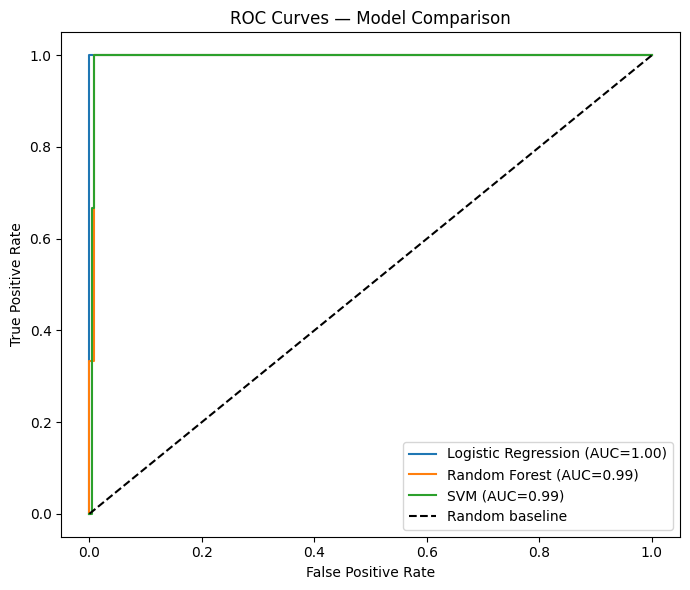


=== Model Comparison Summary ===
                 Model  Accuracy  F1_Score       AUC
0  Logistic Regression  0.920833  0.387097  1.000000
1        Random Forest  0.987500  0.800000  0.994302
2                  SVM  0.954167  0.521739  0.994302


In [ ]:


results = []
fig, ax = plt.subplots(figsize=(7, 6))

for name, model in trained_models.items():
    X_eval = X_test if name == 'Random Forest' else X_test_scaled

    y_pred = model.predict(X_eval)
    y_proba = model.predict_proba(X_eval)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba)

    results.append({'Model': name, 'Accuracy': acc, 'F1_Score': f1, 'AUC': auc})

    print(f"\n=== {name} ===")
    print(f"Accuracy: {acc:.3f} | F1: {f1:.3f} | AUC: {auc:.3f}")
    print(classification_report(y_test, y_pred, zero_division=0))

    fpr, tpr, _ = roc_curve(y_test, y_proba)
    ax.plot(fpr, tpr, label=f"{name} (AUC={auc:.2f})")

ax.plot([0, 1], [0, 1], 'k--', label='Random baseline')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves — Model Comparison')
ax.legend()
plt.tight_layout()
plt.show()

results_df = pd.DataFrame(results).sort_values('AUC', ascending=False)
print("\n=== Model Comparison Summary ===")
print(results_df)

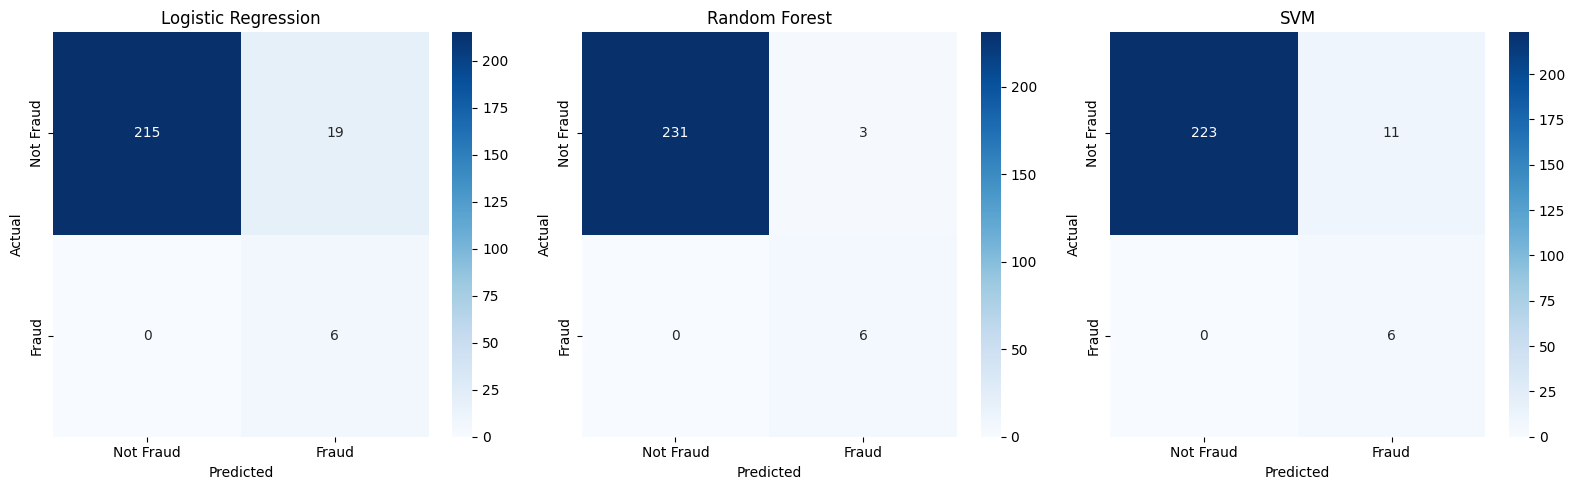

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for i, (name, model) in enumerate(trained_models.items()):
    X_eval = X_test if name == 'Random Forest' else X_test_scaled
    y_pred = model.predict(X_eval)
    cm = confusion_matrix(y_test, y_pred)

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=['Not Fraud', 'Fraud'], yticklabels=['Not Fraud', 'Fraud'])
    axes[i].set_title(name)
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')

plt.tight_layout()
plt.show()